In [109]:
from experiments import (
    load_selfplay_results,
    load_tournament_results
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [110]:
from pathlib import Path


scores = load_selfplay_results (Path("../../results/sp/pd"), 0.05)
# Filter to only include rows where Player index equals Opponent index (self-play)
scores = scores[scores['Player index'] == scores['Opponent index']]
scores = scores[scores['Player index'] == 0].sort_values('repetition')
# scores = scores[scores['repetition'] == ]


In [111]:
scores.head(10)

,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,CC to D count,CD to C count,CD to D count,DC to C count,DC to D count,DD to C count,DD to D count,Good partner,Intended Actions,repetition
0,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCCCCCCCCCCCCDCCCDCDCCDCCDCCDCCDCCCCCCDCCCDCDC...,1976,-45,1000,...,114,42,176,149,60,140,253,1,CCCCCCCCCCCCCDCCCDCDCCDCCDCCDCCDCCCCCCDCCCCCDC...,0
1,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCCCCCCCDCCCCCCDCDDCCDCCDCCDCCDCCCCCCCCCCCCCDD...,2021,45,1000,...,107,61,148,85,133,169,224,0,CCCCCCCCDCCCCCCDCDDCCDCCDCCDCCDCCCCCCCCCCCCCCD...,0
132,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCCCCCDCCCCCCCCCCCCCCCCCCDCCCCCCCCCCCCCCCCCCCC...,1707,-415,1000,...,21,57,160,46,88,134,320,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1
133,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CDCCCCCCCCDCCCDCCCCCDCCCCCCDCDCDCDCDCDDCDCDCDC...,2122,415,1000,...,55,45,89,63,154,80,374,0,CCCCCCCCCCCCCCCCCCCCDCCCCCCDCDCDCDCDCDDCDCDCDC...,1
1584,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCDCC...,2119,235,1000,...,51,62,128,99,139,80,312,0,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCDCC...,2
1585,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCCCCCCCDCCCCCCCCCCCCCCCCCCDCCCCCCCDCCCCDCCCCD...,1884,-235,1000,...,94,81,157,68,122,182,210,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCDCCCCCCCDCCCCCCCCCD...,2
3036,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CDCCCCCCCCCCDCCCCCCCCCDCCCCCCCCCCCCCDCDCDCDCDC...,1793,45,1000,...,50,52,151,91,121,109,401,0,CCCCCCCCCCCCDCCCCCCCCCCCCCCCCCCCCCCCDCDCDCDCDC...,3
3037,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCCCCCCCCCCCDCCCCDCCCCCCDCDCDCDCDCDCDCDCDCDCDC...,1748,-45,1000,...,42,53,159,95,108,105,405,1,CCCCCCCCCCCCCCCCCDCCCCCCDCDCDCDCDCDCDCDCDCDCDC...,3
3168,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CCDCDCCDCDCDCDCDDDCDDDDDDDDDDDDDDDDCDDDCCCDCDC...,1972,-80,1000,...,74,44,218,158,87,133,234,1,CCCCDCCDCDCDCDCDDDCDDDDDDDDDDDDDDDDCDDDCDCDCDC...,4
3169,0,0,0,0,"Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999","Jax QLearner: 0.9, 0.9, 0.1, 1, 0.999",CDCCCDCCCCCDDCCCCDCCCCCCCCCCCCCCCCCCCCCCCCCDDC...,2052,80,1000,...,37,42,203,146,116,94,273,0,CCCCCCCCCCCDCDCCCCCCCCCCCCCCCCCCCCCCCCCCCCCDDC...,4


In [112]:
# Extract action sequences for self-play matches
# Since there's only one type of player index, we can directly use the scores
result_table = (
    scores
    .assign(player_num=lambda df: df.groupby(['repetition', 'Interaction index']).cumcount() + 1)
    .pivot_table(
        index='repetition',
        columns='player_num',
        values='Actions',
        aggfunc='first'
    )
    .rename(columns={1: 'agent1_actions', 2: 'agent2_actions'})
    .reset_index()
)

result_table.head()


player_num,repetition,agent1_actions,agent2_actions
0,0,CCCCCCCCCCCCCDCCCDCDCCDCCDCCDCCDCCCCCCDCCCDCDC...,CCCCCCCCDCCCCCCDCDDCCDCCDCCDCCDCCCCCCCCCCCCCDD...
1,1,CCCCCCDCCCCCCCCCCCCCCCCCCDCCCCCCCCCCCCCCCCCCCC...,CDCCCCCCCCDCCCDCCCCCDCCCCCCDCDCDCDCDCDDCDCDCDC...
2,2,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCDCC...,CCCCCCCCDCCCCCCCCCCCCCCCCCCDCCCCCCCDCCCCDCCCCD...
3,3,CDCCCCCCCCCCDCCCCCCCCCDCCCCCCCCCCCCCDCDCDCDCDC...,CCCCCCCCCCCCDCCCCDCCCCCCDCDCDCDCDCDCDCDCDCDCDC...
4,4,CCDCDCCDCDCDCDCDDDCDDDDDDDDDDDDDDDDCDDDCCCDCDC...,CDCCCDCCCCCDDCCCCDCCCCCCCCCCCCCCCCCCCCCCCCCDDC...


In [113]:
print(len(result_table['agent1_actions'].iloc[0]))

1000


In [114]:
# Build the joint-actions dataframe: timestep, repetition, joint state (CC/DD/CD/DC)
joint_actions_df = (
    result_table
    .assign(
        timestep=lambda df: df.apply(
            lambda r: list(range(min(len(r['agent1_actions']), len(r['agent2_actions'])))), axis=1
        )
    )
    .explode('timestep')
    .assign(
        player=lambda df: df.apply(lambda r: r['agent1_actions'][r['timestep']], axis=1),
        opponent=lambda df: df.apply(lambda r: r['agent2_actions'][r['timestep']], axis=1),
        joint_state=lambda df: df['player'] + df['opponent']
    )
    [['timestep', 'repetition', 'joint_state']]
    .reset_index(drop=True)
)

joint_actions_df.head()

player_num,timestep,repetition,joint_state
0,0,0,CC
1,1,0,CC
2,2,0,CC
3,3,0,CC
4,4,0,CC


In [115]:
# # Group by timestep aggregating joint state by mode over repetitions
# most_common_states = (
#     joint_actions_df
#     .groupby(['timestep'])['joint_state']
#     .agg(lambda x: x.mode().iloc[0])  # Get the most frequent state for each timestep
#     .reset_index()
#     .rename(columns={'joint_state': 'most_common_joint_state'})
# )

# most_common_states.shape

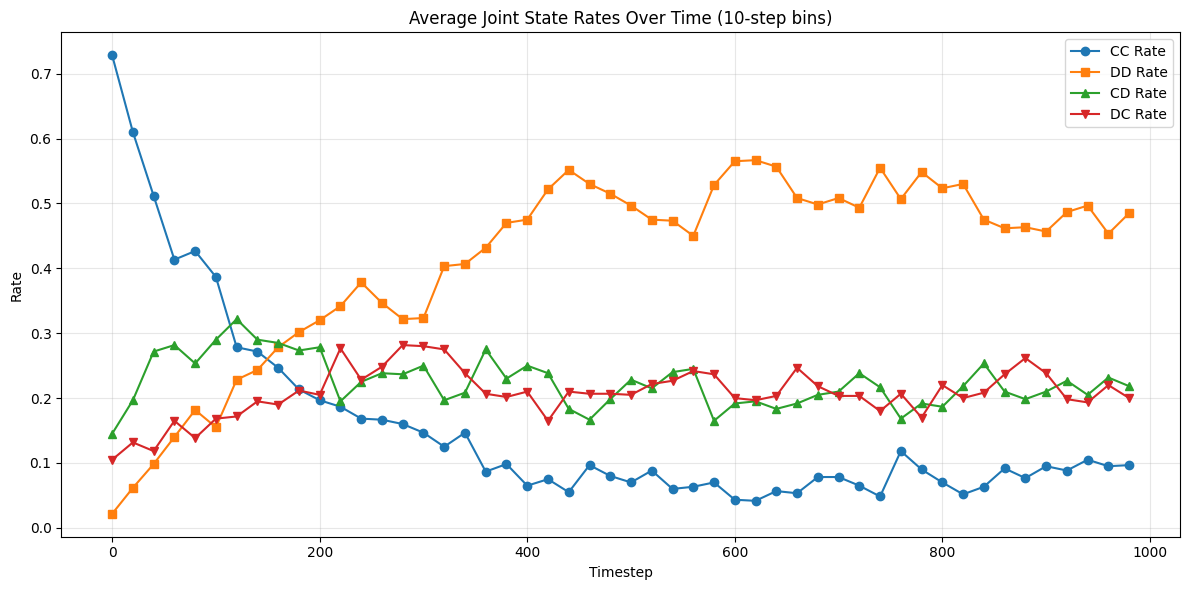

In [116]:
# now we have a table with timestep and state, can we plot the average CC Rate vs DD rate over time? We can do this by aggregating 10 step intervals
bin_size = 20
cc_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'CC').mean())
    .reset_index(name='cc_rate')
    .groupby('bin')['cc_rate']
    .mean()
    .reset_index()
)

dd_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'DD').mean())
    .reset_index(name='dd_rate')
    .groupby('bin')['dd_rate']
    .mean()
    .reset_index()
)

cd_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'CD').mean())
    .reset_index(name='cd_rate')
    .groupby('bin')['cd_rate']
    .mean()
    .reset_index()
)

dc_rates = (
    joint_actions_df
    .assign(
        bin=lambda df: df['timestep'] // bin_size
    )
    .groupby(['bin', 'repetition'])['joint_state']
    .apply(lambda states: (states == 'DC').mean())
    .reset_index(name='dc_rate')
    .groupby('bin')['dc_rate']
    .mean()
    .reset_index()
)

# Plot CC, DD, CD, and DC rates over time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cc_rates['bin'] * bin_size, cc_rates['cc_rate'], label='CC Rate', marker='o')
ax.plot(dd_rates['bin'] * bin_size, dd_rates['dd_rate'], label='DD Rate', marker='s')
ax.plot(cd_rates['bin'] * bin_size, cd_rates['cd_rate'], label='CD Rate', marker='^')
ax.plot(dc_rates['bin'] * bin_size, dc_rates['dc_rate'], label='DC Rate', marker='v')
ax.set_xlabel('Timestep')
ax.set_ylabel('Rate')
ax.set_title('Average Joint State Rates Over Time (10-step bins)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [117]:
# # now we have a table with timestep and state, can we plot the average CC Rate vs DD rate over time? We can do this by computing a rolling average
# window = 10  # rolling window size

# # Compute rolling rates for each repetition
# cc_rates = (
#     joint_actions_df
#     .groupby(['repetition', 'timestep'])['joint_state']
#     .apply(lambda states: states.eq('CC').rolling(window, min_periods=1).mean())
#     .reset_index(level=0, drop=True)
#     .reset_index()
#     .groupby('timestep')['joint_state']
#     .mean()
#     .reset_index()
#     .rename(columns={'joint_state': 'cc_rate'})
# )

# dd_rates = (
#     joint_actions_df
#     .groupby(['repetition', 'timestep'])['joint_state']
#     .apply(lambda states: states.eq('DD').rolling(window, min_periods=1).mean())
#     .reset_index(level=0, drop=True)
#     .reset_index()
#     .groupby('timestep')['joint_state']
#     .mean()
#     .reset_index()
#     .rename(columns={'joint_state': 'dd_rate'})
# )

# cd_rates = (
#     joint_actions_df
#     .groupby(['repetition', 'timestep'])['joint_state']
#     .apply(lambda states: states.eq('CD').rolling(window, min_periods=1).mean())
#     .reset_index(level=0, drop=True)
#     .reset_index()
#     .groupby('timestep')['joint_state']
#     .mean()
#     .reset_index()
#     .rename(columns={'joint_state': 'cd_rate'})
# )

# dc_rates = (
#     joint_actions_df
#     .groupby(['repetition', 'timestep'])['joint_state']
#     .apply(lambda states: states.eq('DC').rolling(window, min_periods=1).mean())
#     .reset_index(level=0, drop=True)
#     .reset_index()
#     .groupby('timestep')['joint_state']
#     .mean()
#     .reset_index()
#     .rename(columns={'joint_state': 'dc_rate'})
# )

# # Plot CC, DD, CD, and DC rates over time
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(cc_rates['timestep'], cc_rates['cc_rate'], label='CC Rate')
# ax.plot(dd_rates['timestep'], dd_rates['dd_rate'], label='DD Rate')
# ax.plot(cd_rates['timestep'], cd_rates['cd_rate'], label='CD Rate')
# ax.plot(dc_rates['timestep'], dc_rates['dc_rate'], label='DC Rate')
# ax.set_xlabel('Timestep')
# ax.set_ylabel('Rate')
# ax.set_title(f'Average Joint State Rates Over Time ({window}-step rolling average)')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()
